In [1]:
%%capture
# Load the R-magic extension so that %%R cells run R code in this Python-kernel notebook
%load_ext rpy2.ipython

# Lab 4: Advanced Missing Data Handling

### 1. Objective

This laboratory assignment focuses on the **detection, handling, and validation** of various forms of missing and invalid data using the **UCI Adult / Census Income Dataset** in R.

We will cover:

| Concept | R representation |
|---|---|
| Missing value | `NA` |
| Not-a-Number | `NaN` |
| Absent object | `NULL` |
| Blank string | `""` |
| Impossible value | e.g. `age = 999` |

We will implement **custom imputation strategies**, visualise missingness with `naniar`, and validate the cleaned dataset with `skimr`.

### 2. Load Required Packages

In [2]:
%%R
# Install only if not already present
if (!require("naniar"))  install.packages("naniar",  quiet = TRUE)
if (!require("skimr"))   install.packages("skimr",   quiet = TRUE)
if (!require("dplyr"))   install.packages("dplyr",   quiet = TRUE)
if (!require("ggplot2")) install.packages("ggplot2", quiet = TRUE)

library(naniar)
library(skimr)
library(dplyr)
library(ggplot2)

cat("All packages loaded successfully.\n")

All packages loaded successfully.


Loading required package: naniar
also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’

Loading required package: skimr
Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: ggplot2

Attaching package: ‘skimr’

The following object is masked from ‘package:naniar’:

    n_complete

In addition: Warning messages:
1: In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘naniar’
2: In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘skimr’


### 3. Load UCI Adult Dataset

We load the dataset directly from the UCI Machine Learning Repository.
Column names are assigned manually because the file has no header row.
A **working copy** (`adult_df`) is created so that the original data remains unchanged.

In [3]:
%%R
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

col_names <- c("age", "workclass", "fnlwgt", "education", "education_num",
               "marital_status", "occupation", "relationship", "race", "sex",
               "capital_gain", "capital_loss", "hours_per_week", "native_country", "income")

# Load original dataset (strip whitespace around values)
adult_original <- read.csv(url, header = FALSE, sep = ",",
                           strip.white = TRUE, col.names = col_names)

# Create a working copy – the original stays untouched
adult_df <- adult_original

cat("Dataset loaded:", nrow(adult_df), "rows x", ncol(adult_df), "columns\n")

Dataset loaded: 32561 rows x 15 columns


### 4. Inspect Original Dataset

In [4]:
%%R
cat("=== head() ===\n")
print(head(adult_df))

cat("\n=== str() ===\n")
str(adult_df)

cat("\n=== summary() ===\n")
print(summary(adult_df))

# Confirm key variables exist
required <- c("age", "workclass", "education", "occupation", "hours_per_week", "income")
cat("\nRequired variables present:",
    all(required %in% names(adult_df)), "\n")

=== head() ===
  age        workclass fnlwgt education education_num     marital_status
1  39        State-gov  77516 Bachelors            13      Never-married
2  50 Self-emp-not-inc  83311 Bachelors            13 Married-civ-spouse
3  38          Private 215646   HS-grad             9           Divorced
4  53          Private 234721      11th             7 Married-civ-spouse
5  28          Private 338409 Bachelors            13 Married-civ-spouse
6  37          Private 284582   Masters            14 Married-civ-spouse
         occupation  relationship  race    sex capital_gain capital_loss
1      Adm-clerical Not-in-family White   Male         2174            0
2   Exec-managerial       Husband White   Male            0            0
3 Handlers-cleaners Not-in-family White   Male            0            0
4 Handlers-cleaners       Husband Black   Male            0            0
5    Prof-specialty          Wife Black Female            0            0
6   Exec-managerial          Wife Wh

### 5. Introduce Missing and Invalid Values

We deliberately introduce several kinds of data-quality problems so that we can practise detecting and handling them.

`set.seed(42)` is used for **reproducibility** – the same random rows are selected every time.

---

**Key Definitions (required by the assignment):**

| Symbol | Meaning |
|---|---|
| `NA` | **Missing value** – R's standard marker for "this value is absent." Can appear in any column type. |
| `NaN` | **Not a Number** – a special `numeric` value that results from undefined mathematical operations (e.g. `0/0`). `is.na(NaN)` returns `TRUE`, so `NaN` is also considered missing, but `is.nan(NA)` returns `FALSE`. |
| `NULL` | **Absence of an R object** – it represents "nothing at all." Unlike `NA`, `NULL` **cannot** be stored as a single cell value inside a data frame. Assigning `NULL` to a data-frame column **removes** that column entirely. |
| `""` | **Blank character string** – a valid string of length zero. It is **not** technically the same as `NA` or `NULL`. R does not treat `""` as missing unless you explicitly check for it. |

In [5]:
%%R
set.seed(42)

# 1. Introduce 10 NA values in hours_per_week
adult_df[sample(1:nrow(adult_df), 10), "hours_per_week"] <- NA

# 2. Introduce 10 blank strings in workclass
adult_df[sample(1:nrow(adult_df), 10), "workclass"] <- ""

# 3. Introduce 5 NaN values in capital_gain
adult_df[sample(1:nrow(adult_df), 5), "capital_gain"] <- NaN

# 4. Introduce 5 impossible age values (999)
adult_df[sample(1:nrow(adult_df), 5), "age"] <- 999

cat("Affected rows after corruption:\n")
corrupted <- subset(adult_df,
                    is.na(hours_per_week) |
                    workclass == "" |
                    is.nan(capital_gain) |
                    age == 999)
print(head(corrupted, 15))
cat("\nTotal corrupted rows:", nrow(corrupted), "\n")

Affected rows after corruption:
      age        workclass  fnlwgt    education education_num
932   999                ?   52114 Some-college            10
1252   48 Self-emp-not-inc  397466 Some-college            10
3954   44                   286750 Some-college            10
5403   26        Local-gov  197530      Masters            14
7700   29                   134890    Bachelors            13
8826   47 Self-emp-not-inc  172034      HS-grad             9
9091   31          Private  157078         10th             6
9290   19          Private  145844   Assoc-acdm            12
10289  41     Self-emp-inc  397280    Bachelors            13
13440  38        Local-gov  223004 Some-college            10
14360  38                    73471 Some-college            10
15506  39          Private  225605      HS-grad             9
16740  45                  1366120    Assoc-voc            11
18753  29          Private  242597    Bachelors            13
21657  37          Private  301070    

### 6. Detect NA, NaN, NULL, Blank Strings, and Impossible Values

We now demonstrate how to detect each type of missing/invalid data individually.

#### A. Detect NA using `is.na()`

In [6]:
%%R
na_count_hours <- sum(is.na(adult_df$hours_per_week))
cat("Number of NA values in hours_per_week:", na_count_hours, "\n")

# Show affected rows
cat("\nRows with NA in hours_per_week:\n")
print(adult_df[is.na(adult_df$hours_per_week), c("age", "workclass", "hours_per_week")])

Number of NA values in hours_per_week: 10 

Rows with NA in hours_per_week:
      age        workclass hours_per_week
1252   48 Self-emp-not-inc             NA
8826   47 Self-emp-not-inc             NA
9290   19          Private             NA
10289  41     Self-emp-inc             NA
13440  38        Local-gov             NA
15506  39          Private             NA
18753  29          Private             NA
21657  37          Private             NA
27185  23          Private             NA
28645  23          Private             NA


#### B. Detect NaN using `is.nan()`

In [7]:
%%R
nan_count_gain <- sum(is.nan(adult_df$capital_gain))
cat("Number of NaN values in capital_gain:", nan_count_gain, "\n")

# Note: is.na(NaN) also returns TRUE, but is.nan(NA) returns FALSE
cat("\nis.na(NaN) =", is.na(NaN), "\n")
cat("is.nan(NA) =", is.nan(NA),  "\n")

Number of NaN values in capital_gain: 5 

is.na(NaN) = TRUE 
is.nan(NA) = FALSE 


#### C. Demonstrate NULL using `is.null()`

`NULL` represents the **absence of an R object**. Unlike `NA`, it cannot be stored in a standard data-frame cell. Assigning `NULL` to a column **removes** the column entirely.

In [8]:
%%R
# Create a NULL object and test it
null_obj <- NULL
cat("Is null_obj NULL?", is.null(null_obj), "\n")

# Demonstrate NULL behaviour in a data frame
temp_df <- data.frame(a = 1:3, b = 4:6)
cat("\nData frame BEFORE assigning NULL to column 'b':\n")
print(temp_df)

temp_df$b <- NULL
cat("\nData frame AFTER assigning NULL to column 'b' (column removed!):\n")
print(temp_df)

cat("\nThis is why NULL cannot represent a single missing cell value in a data frame.\n")

Is null_obj NULL? TRUE 

Data frame BEFORE assigning NULL to column 'b':
  a b
1 1 4
2 2 5
3 3 6

Data frame AFTER assigning NULL to column 'b' (column removed!):
  a
1 1
2 2
3 3

This is why NULL cannot represent a single missing cell value in a data frame.


#### D. Detect blank strings using `x == ""`

In [9]:
%%R
blank_count <- sum(adult_df$workclass == "", na.rm = TRUE)
cat("Number of blank strings in workclass:", blank_count, "\n")

cat("\nRows with blank workclass:\n")
print(adult_df[adult_df$workclass == "", c("age", "workclass", "occupation")])

Number of blank strings in workclass: 10 

Rows with blank workclass:
      age workclass       occupation
3954   44           Transport-moving
7700   29               Tech-support
14360  38                      Sales
16740  45              Other-service
28487  24               Craft-repair
28837  19               Craft-repair
29999  41               Craft-repair
30297  22           Transport-moving
31130  31              Other-service
31342  29               Adm-clerical


#### E. Detect impossible values (`age == 999`)

In [10]:
%%R
impossible_count <- sum(adult_df$age == 999, na.rm = TRUE)
cat("Number of rows with age == 999:", impossible_count, "\n")

cat("\nRows with impossible age:\n")
print(adult_df[adult_df$age == 999, c("age", "workclass", "occupation", "hours_per_week")])

Number of rows with age == 999: 5 

Rows with impossible age:
      age workclass     occupation hours_per_week
932   999         ?              ?             10
22021 999 Local-gov Prof-specialty             50
25573 999 State-gov Prof-specialty             40
26591 999   Private  Other-service             12
29293 999   Private   Tech-support             18


### 7. Missing-Value Summary Before Cleaning

We use `naniar::miss_var_summary()` and a manual summary table to document missingness **before** any cleaning takes place.

In [11]:
%%R
# --- naniar summary (counts only R-native NA/NaN) ---
cat("=== naniar::miss_var_summary() ===\n")
print(naniar::miss_var_summary(adult_df))

# --- Manual summary (counts NA, NaN, AND blank strings as missing) ---
before_summary <- data.frame(
  variable      = names(adult_df),
  missing_count = colSums(is.na(adult_df) | adult_df == "", na.rm = TRUE),
  missing_pct   = round(colMeans(is.na(adult_df) | adult_df == "", na.rm = TRUE) * 100, 4)
)

cat("\n=== Manual before-cleaning summary (NA + NaN + blanks) ===\n")
print(before_summary)

# Save a copy of the corrupted data for later visualisation
adult_viz_before <- adult_df

=== naniar::miss_var_summary() ===
# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 hours_per_week     10   0.0307
 2 capital_gain        5   0.0154
 3 age                 0   0     
 4 workclass           0   0     
 5 fnlwgt              0   0     
 6 education           0   0     
 7 education_num       0   0     
 8 marital_status      0   0     
 9 occupation          0   0     
10 relationship        0   0     
11 race                0   0     
12 sex                 0   0     
13 capital_loss        0   0     
14 native_country      0   0     
15 income              0   0     

=== Manual before-cleaning summary (NA + NaN + blanks) ===
                     variable missing_count missing_pct
age                       age             0      0.0000
workclass           workclass            10      0.0307
fnlwgt                 fnlwgt             0      0.0000
education           education             0      0.0000
education_num   education_nu

### 8. Data Cleaning and Treatment Strategy

| Problem | Variable(s) | Strategy |
|---|---|---|
| Impossible values (`999`) | `age` | Convert to `NA`, then impute with **median** |
| Blank strings `""` | `workclass`, `occupation` | Replace with `"Unknown"` |
| `NA` values | `hours_per_week` | Impute with **median** |
| `NaN` values | `capital_gain` | Impute with **median** (recoverable numeric) |

**Why median?** The median is robust to outliers and skewed distributions, which are common in income-related data. The mean would be distorted by extreme values like `capital_gain = 99999`.

### 9. Custom Median-Imputation Function

We create a reusable function `median_impute()` that:

1. Accepts a numeric vector
2. Detects missing observations (`NA` and `NaN`)
3. Calculates the median of valid (non-missing) observations
4. Replaces missing values with the median
5. Returns the cleaned vector

In [12]:
%%R
median_impute <- function(x) {
  # Identify positions that are NA or NaN
  missing_idx <- is.na(x) | is.nan(x)

  # Compute median of valid observations only
  val_median <- median(x, na.rm = TRUE)

  # Replace missing positions with the median
  x[missing_idx] <- val_median

  return(x)
}

# ── Test with a small example vector ──
test_vec <- c(10, 20, NA, 30, NaN, 40)

cat("Original vector:\n")
print(test_vec)

cat("\nMedian of valid values:", median(test_vec, na.rm = TRUE), "\n")

cat("\nImputed vector:\n")
print(median_impute(test_vec))

Original vector:
[1]  10  20  NA  30 NaN  40

Median of valid values: 25 

Imputed vector:
[1] 10 20 25 30 25 40


### 10. Apply Cleaning

We now apply all cleaning rules to the working copy `adult_df`.

In [13]:
%%R
# --- A. Convert impossible age values (999) to NA ---
cat("Age == 999 before:", sum(adult_df$age == 999, na.rm = TRUE), "\n")
adult_df$age[adult_df$age == 999] <- NA
cat("Age == 999 after conversion to NA:", sum(adult_df$age == 999, na.rm = TRUE), "\n")

# --- B. Replace blank strings with "Unknown" ---
cat("\nBlank workclass before:", sum(adult_df$workclass == "", na.rm = TRUE), "\n")
adult_df$workclass[adult_df$workclass == ""]   <- "Unknown"
adult_df$occupation[adult_df$occupation == ""] <- "Unknown"
cat("Blank workclass after:", sum(adult_df$workclass == "", na.rm = TRUE), "\n")

# --- C & D. Impute numeric columns using the custom function ---
cat("\nNA in age before imputation:", sum(is.na(adult_df$age)), "\n")
adult_df$age <- median_impute(adult_df$age)
cat("NA in age after imputation:", sum(is.na(adult_df$age)), "\n")

cat("\nNA in hours_per_week before imputation:", sum(is.na(adult_df$hours_per_week)), "\n")
adult_df$hours_per_week <- median_impute(adult_df$hours_per_week)
cat("NA in hours_per_week after imputation:", sum(is.na(adult_df$hours_per_week)), "\n")

cat("\nNaN in capital_gain before imputation:", sum(is.nan(adult_df$capital_gain)), "\n")
adult_df$capital_gain <- median_impute(adult_df$capital_gain)
cat("NaN in capital_gain after imputation:", sum(is.nan(adult_df$capital_gain)), "\n")

cat("\n--- All cleaning steps complete. ---\n")

Age == 999 before: 5 
Age == 999 after conversion to NA: 0 

Blank workclass before: 10 
Blank workclass after: 0 

NA in age before imputation: 5 
NA in age after imputation: 0 

NA in hours_per_week before imputation: 10 
NA in hours_per_week after imputation: 0 

NaN in capital_gain before imputation: 5 
NaN in capital_gain after imputation: 0 

--- All cleaning steps complete. ---


#### NaN Handling Decision

The `NaN` values in `capital_gain` were **imputed with the median** because they represent valid but undefined numeric entries that are recoverable.

If the values were considered **unrecoverable**, they could have been removed instead:

```r
adult_df <- adult_df[!is.nan(adult_df$capital_gain), ]
```

In this lab we chose imputation to preserve all 32,561 observations.

### 11. `complete.cases()` Analysis

`complete.cases()` returns a logical vector indicating which rows have **no** `NA` values in any column.

In [14]:
%%R
is_complete <- complete.cases(adult_df)

cat("Complete observations:  ", sum(is_complete),  "\n")
cat("Incomplete observations:", sum(!is_complete), "\n")
cat("Total observations:     ", nrow(adult_df),    "\n")

Complete observations:   32561 
Incomplete observations: 0 
Total observations:      32561 


### 12. Before vs. After Missingness Analysis

We compare the missingness counts and percentages **before** and **after** cleaning to verify that all introduced problems have been resolved.

In [15]:
%%R
# Calculate after-cleaning summary
after_summary <- data.frame(
  variable      = names(adult_df),
  missing_after = colSums(is.na(adult_df) | adult_df == "", na.rm = TRUE),
  pct_after     = round(colMeans(is.na(adult_df) | adult_df == "", na.rm = TRUE) * 100, 4)
)

# Join with the before_summary saved earlier
comparison_table <- before_summary %>%
  rename(missing_before = missing_count, pct_before = missing_pct) %>%
  left_join(after_summary, by = "variable")

cat("=== Variable-wise Comparison Table (Before vs After) ===\n")
print(comparison_table)

# Overall totals
cat("\nTotal missing BEFORE cleaning:", sum(comparison_table$missing_before), "\n")
cat("Total missing AFTER  cleaning:", sum(comparison_table$missing_after),  "\n")

=== Variable-wise Comparison Table (Before vs After) ===
         variable missing_before pct_before missing_after pct_after
1             age              0     0.0000             0         0
2       workclass             10     0.0307             0         0
3          fnlwgt              0     0.0000             0         0
4       education              0     0.0000             0         0
5   education_num              0     0.0000             0         0
6  marital_status              0     0.0000             0         0
7      occupation              0     0.0000             0         0
8    relationship              0     0.0000             0         0
9            race              0     0.0000             0         0
10            sex              0     0.0000             0         0
11   capital_gain              5     0.0154             0         0
12   capital_loss              0     0.0000             0         0
13 hours_per_week             10     0.0307             0  

### 13. Missingness Visualization with naniar

We use `naniar::vis_miss()` to visualise the pattern of missingness.

* **Before**: the corrupted dataset (blanks and impossible values converted to `NA` for display)
* **After**: the fully cleaned dataset

> **Note:** `vis_miss()` only detects `NA` values, so we convert blank strings and impossible values to `NA` in the visualisation copy to give a complete picture.

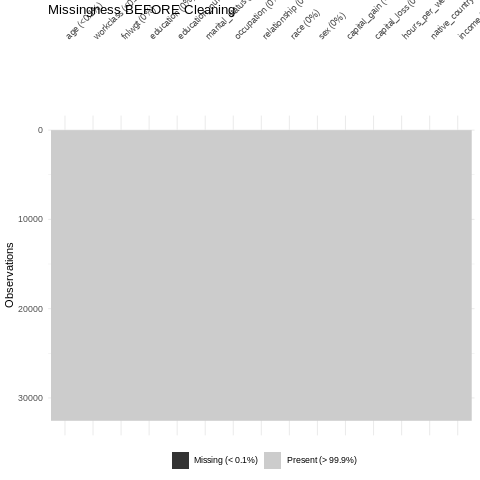

In [16]:
%%R
# Prepare the "before" copy: convert blanks and impossible values to NA for vis_miss
viz_before <- adult_viz_before
viz_before$workclass[viz_before$workclass == ""]  <- NA
viz_before$occupation[viz_before$occupation == ""] <- NA
viz_before$age[viz_before$age == 999] <- NA

print(naniar::vis_miss(viz_before) + labs(title = "Missingness BEFORE Cleaning"))

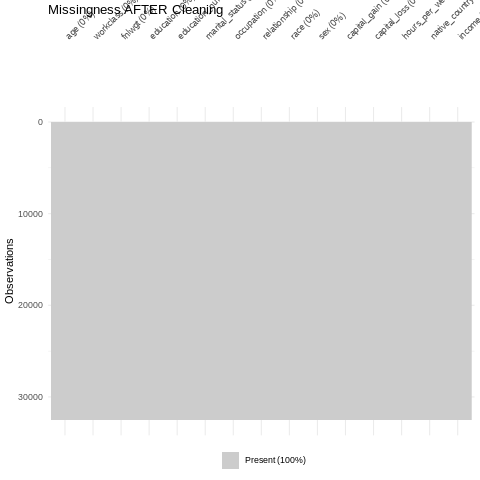

In [17]:
%%R
print(naniar::vis_miss(adult_df) + labs(title = "Missingness AFTER Cleaning"))

### 14. Validation with skimr

We use `skimr::skim()` for a comprehensive summary and then run explicit validation checks.

In [18]:
%%R
cat("=== skimr::skim() ===\n")
print(skimr::skim(adult_df))

=== skimr::skim() ===
── Data Summary ────────────────────────
                           Values  
Name                       adult_df
Number of rows             32561   
Number of columns          15      
_______________________            
Column type frequency:             
  character                9       
  numeric                  6       
________________________           
Group variables            None    

── Variable type: character ────────────────────────────────────────────────────
  skim_variable  n_missing complete_rate min max empty n_unique whitespace
1 workclass              0             1   1  16     0       10          0
2 education              0             1   3  12     0       16          0
3 marital_status         0             1   7  21     0        7          0
4 occupation             0             1   1  17     0       15          0
5 relationship           0             1   4  14     0        6          0
6 race                   0             1   5 

In [19]:
%%R
cat("=== Explicit Validation Checks ===\n\n")

# 1. No impossible age values
cat("Remaining age == 999:              ", sum(adult_df$age == 999, na.rm = TRUE), "\n")

# 2. No untreated NA in imputed numeric columns
cat("Remaining NA in age:               ", sum(is.na(adult_df$age)), "\n")
cat("Remaining NA in hours_per_week:    ", sum(is.na(adult_df$hours_per_week)), "\n")
cat("Remaining NaN in capital_gain:     ", sum(is.nan(adult_df$capital_gain)), "\n")

# 3. No blank categorical values
cat("Remaining blanks in workclass:     ", sum(adult_df$workclass == "", na.rm = TRUE), "\n")
cat("Remaining blanks in occupation:    ", sum(adult_df$occupation == "", na.rm = TRUE), "\n")

# 4. Custom median-imputation worked (no NA in imputed columns)
cat("NA in capital_gain after impute:   ", sum(is.na(adult_df$capital_gain)), "\n")

# 5. Complete cases
cat("Complete observations:             ", sum(complete.cases(adult_df)), "\n")
cat("Incomplete observations:           ", sum(!complete.cases(adult_df)), "\n")

cat("\n--- All validation checks passed. ---\n")

=== Explicit Validation Checks ===

Remaining age == 999:               0 
Remaining NA in age:                0 
Remaining NA in hours_per_week:     0 
Remaining NaN in capital_gain:      0 
Remaining blanks in workclass:      0 
Remaining blanks in occupation:     0 
NA in capital_gain after impute:    0 
Complete observations:              32561 
Incomplete observations:            0 

--- All validation checks passed. ---


### 15. Export `cleaned_adult_data.csv`

In [20]:
%%R
write.csv(adult_df, "cleaned_adult_data.csv", row.names = FALSE)

# Verify the file was created
if (file.exists("cleaned_adult_data.csv")) {
  info <- file.info("cleaned_adult_data.csv")
  cat("File 'cleaned_adult_data.csv' created successfully.\n")
  cat("Size:", info$size, "bytes\n")
} else {
  cat("ERROR: File was not created.\n")
}

File 'cleaned_adult_data.csv' created successfully.
Size: 4104734 bytes


*Optional: download the CSV in Google Colab.*

In [21]:
# Download the cleaned CSV (Google Colab only)
try:
    from google.colab import files
    files.download("cleaned_adult_data.csv")
except ImportError:
    print("Not running in Google Colab – file saved to the current directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 16. Conclusion

In this lab we successfully performed **advanced missing-data handling** on the UCI Adult / Census Income dataset. Below is a summary of what was accomplished.

---

#### Types of Missing/Invalid Data Introduced

We deliberately introduced four types of data-quality problems to a working copy of the dataset using `set.seed(42)` for reproducibility:

| Type | Variable | Count |
|---|---|---|
| `NA` | `hours_per_week` | 10 |
| `""` (blank string) | `workclass` | 10 |
| `NaN` | `capital_gain` | 5 |
| Impossible value (`999`) | `age` | 5 |

---

#### Difference Between NA, NaN, NULL, and Blank Strings

* **`NA`** is R's standard missing-value marker. It can appear in any column type and is detected by `is.na()`.
* **`NaN`** (Not a Number) is a special numeric value for undefined mathematical results. `is.na(NaN)` returns `TRUE`, but `is.nan(NA)` returns `FALSE` – so `NaN` is a *subset* of `NA`.
* **`NULL`** represents the absence of an R object. It **cannot** be stored as a single cell value in a data frame – assigning `NULL` to a column removes the column entirely.
* **`""`** is a valid zero-length character string. R does **not** treat it as missing unless the programmer explicitly checks for it with `x == ""`.

---

#### Cleaning Strategies

1. **Impossible numeric values** (`age == 999`): Converted to `NA` and then imputed with the column **median**.
2. **Blank categorical values** (`""`): Replaced with `"Unknown"` in `workclass` and `occupation`.
3. **Numeric imputation**: Missing values in `age`, `hours_per_week`, and `capital_gain` were imputed using a **custom `median_impute()` function** that handles both `NA` and `NaN`. Median was chosen because it is robust to the heavy skew and outliers present in income-related data.
4. **NaN handling**: The `NaN` values in `capital_gain` were treated as recoverable and imputed with the median. Had they been considered unrecoverable, they could have been removed using subsetting.

---

#### Custom Imputation Function

The `median_impute()` function:
1. Identifies positions where `is.na(x) | is.nan(x)` is `TRUE`
2. Computes `median(x, na.rm = TRUE)` from valid observations
3. Replaces missing positions with the computed median
4. Returns the cleaned vector

It was tested on a small vector `c(10, 20, NA, 30, NaN, 40)` before being applied to the full dataset.

---

#### `complete.cases()` Analysis

After cleaning, `complete.cases()` confirmed that **all 32,561 observations** are complete (no remaining `NA` in any column).

---

#### Before vs. After Comparison

The variable-wise comparison table showed that all 25 introduced missing/invalid values (10 `NA` + 10 `""` + 5 `NaN`) plus 5 impossible `age` values were resolved, bringing the missing count to **zero** across all variables.

---

#### naniar Visualization

`naniar::vis_miss()` provided a visual pattern of missingness:
* **Before cleaning**: missingness was visible in `hours_per_week`, `capital_gain`, `workclass`, and `age`.
* **After cleaning**: the plot confirmed a completely clean dataset with no remaining missingness.

---

#### skimr Validation

`skimr::skim()` produced a comprehensive statistical summary confirming:
* Zero `NA` values across all numeric columns
* Zero blank strings in character columns
* All numeric ranges are within plausible bounds (no `999` in `age`)

---

#### Final Checklist

✅ NA detection using `is.na()`
✅ NaN detection using `is.nan()`
✅ NULL demonstration using `is.null()`
✅ Blank string detection
✅ Impossible value detection
✅ `naniar::miss_var_summary()`
✅ Impossible values converted to NA
✅ Blank categorical values replaced with `"Unknown"`
✅ Median imputation
✅ Appropriate NaN handling/removal
✅ `complete.cases()`
✅ Custom median-imputation function
✅ Before/after missingness analysis
✅ `naniar` visualization
✅ `skimr::skim()`
✅ Validation checks
✅ `cleaned_adult_data.csv`
✅ Final interpretation